In [1]:
import scanpy as sc
import os
import pandas as pd
import matplotlib as mpl
import sys
import numpy as np
import matplotlib.pyplot as plt
import diffxpy.api as de
sys.path.append('/wsfish/glioblastoma/')
import FISHspace as sp
import shoji
%reload_ext autoreload
%autoreload 2

mpl.rcParams['pdf.fonttype'] = 42

# save figure with no pad
mpl.rcParams['savefig.pad_inches'] = 0
mpl.rcParams['savefig.bbox'] = 'tight'

# set axes width
mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams['xtick.minor.pad'] = 2
mpl.rcParams['xtick.major.pad'] = 2
mpl.rcParams['ytick.minor.pad'] = 2
mpl.rcParams['ytick.major.pad'] = 2
mpl.rcParams['xtick.minor.width'] = 2
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['ytick.minor.width'] = 2
mpl.rcParams['ytick.major.width'] = 2

# use colorblind seaborn style
plt.style.use('seaborn-colorblind')

/home/alejandro/miniconda3/envs/py39/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
2024-06-15 03:05:23.875301: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-15 03:05:31.749888: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/wsfish/glioblastoma/FISHspace/tools/microenv/cci/het.py:192: NumbaDeprecationWarning: The keyword argument 'nopython=False' was supplied. From Numba 0.59.0 the default is being changed to True and use of 'nopython=False' will raise a warning as the argument will have no effect. See https://numba.readthedocs.io/en/stabl

In [2]:
db = shoji.connect()

In [3]:
SL040 = db.builds.jesper.GBM_all.SL040

In [5]:
np.unique(SL040.Location[:])

array(['Ant high fluo', 'Ant low fluo', 'Ant no fluo', 'Cortex',
       'Inf high fluo', 'Inf no fluo', 'Necrotic core', 'Pos high fluo',
       'Pos no fluo', 'Sup high fluo', 'Sup low fluo', 'Sup no fluo'],
      dtype=object)

In [7]:
dic = {s:l for s,l in zip(SL040.Sample[:], SL040.Location[:])}

In [8]:
dic

{'SL040B': 'Ant high fluo',
 'SL040J': 'Sup no fluo',
 'SL040K': 'Inf no fluo',
 'SL040C': 'Ant low fluo',
 'SL040D': 'Ant no fluo',
 'SL040I': 'Sup low fluo',
 'SL040E': 'Pos high fluo',
 'SL040A': 'Cortex',
 'SL040F': 'Pos no fluo',
 'SL040G': 'Necrotic core',
 'SL040H': 'Sup high fluo',
 'SL040L': 'Inf high fluo'}

In [10]:
location_palette = {
    'core':'#c44d56',
    'high':'#f1d693',
    'low':'#19b5fe',
    'periphery':'#66cc99',   
}

location_dic = {
    'Ant high fluo':'high', 
    'Ant low fluo':'low', 
    'Ant no fluo':'periphery', 
    'Cortex':'periphery',
    'Inf high fluo': 'high', 
    'Inf no fluo':'periphery', 
    'Necrotic core':'core', 
    'Pos high fluo':'high', 
    'Pos no fluo':'periphery', 
    'Sup high fluo':'high', 
    'Sup low fluo':'low', 
    'Sup no fluo':'periphery',
}


In [11]:
neftelscore = SL040.NeftelScore[:]

In [12]:
neftelscore.shape

(135482, 4)

In [13]:
emb = SL040.Embedding[:]
genes = SL040.Gene[:]
exp = SL040.Expression[:]

In [14]:
def plot_gene(
    gene,
    gene_order,
    exp,
    emb,
    s=1,
    figsize=(6,6),
    ):
    fig, ax = plt.subplots(figsize=figsize, nrows=1, ncols=1)
    ax.set_xticks([])
    ax.set_yticks([])

    expression_gene = exp[:,gene_order == gene]
    zeros = expression_gene
    xy = emb
    bgval = 0

    cells = expression_gene > bgval
    cells = cells[:,0]
    color = expression_gene[cells]
    order = color.argsort(axis=0)

    xy_ = xy[cells]
    xy_ = xy_[order][:,0,:]
    color = color[order][:,0,0]
    color = np.log(color + 1)

    ax.scatter(xy[:, 0], xy[:, 1], c="lightgrey", s=s/10, alpha=.5, rasterized=True)
    ax.scatter(xy_[:,0], xy_[:,1], c=color, s=s, cmap='magma', alpha=1, rasterized=True)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    

def plot_score(
    score,
    emb,
    #min_quant=.01,
    #max_quant=.99,
    log = True,
    cmap='PiYG',
    s=1,
    figsize=(6,6),
    filename=None
    ):
    
    fig, ax = plt.subplots(figsize=figsize, nrows=1, ncols=1)
    ax.set_xticks([])
    ax.set_yticks([])

    xy = emb
    #bgval = np.quantile(score, min_quant)
    #cells = expression_gene > bgval
    #cells = cells[:,0]
    color = score
    order = color.argsort(axis=0)
    #xy_ = xy[cells]
    xy_ = xy[order]
    color = color[order]
    
    ax.scatter(xy_[:,0], xy_[:,1], c=color, s=s, cmap=cmap, alpha=1, rasterized=True,)
    ax.axis('off')
    plt.tight_layout()
    if filename is not None:
        plt.savefig(f'figures/{filename}.png',format='png', dpi=300,transparent=True)
        
    plt.show()
    
def plot_region(
    loc,
    emb,
    s=1,
    figsize=(6,6),
    ):
    fig, ax = plt.subplots(figsize=figsize, nrows=1, ncols=1)
    ax.set_xticks([])
    ax.set_yticks([])

    xy = emb
    color = [location_palette[location_dic[l]] for l in loc]
    ax.scatter(xy[:,0], xy[:,1], c=color, s=s, alpha=1, rasterized=True)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


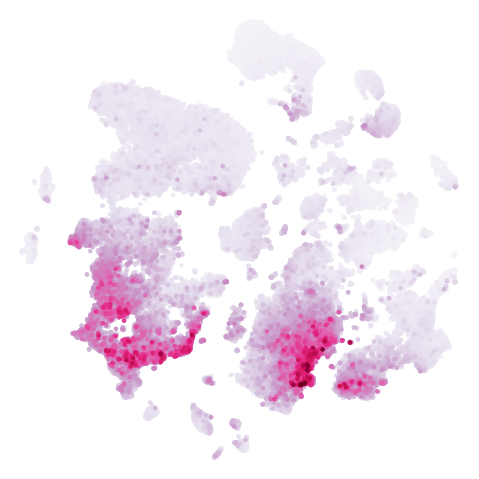

In [309]:

plot_score( 
    neftelscore[:,1],
    emb,
    cmap='PuRd',
    s=5,
    figsize=(5,5),
    filename='NeftelScoreMES'
)


In [18]:
annotation = SL040.ManualAnnotationSL040[:]

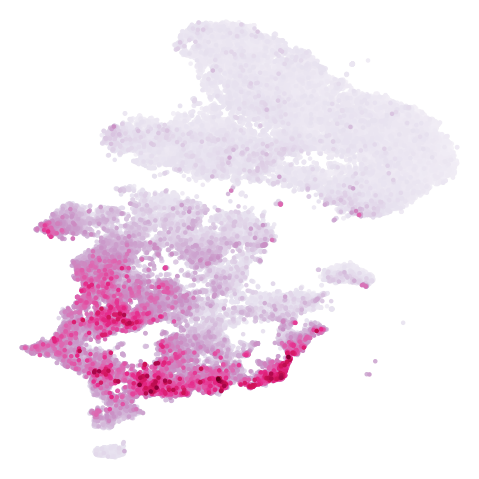

In [19]:
f = np.isin(annotation,['MgTAM','Microglia', 'MoTAM', 'Monocytes'])
plot_score( 
    neftelscore[:,1][f],
    emb[f,:],
    cmap='PuRd',
    s=5,
    figsize=(5,5),
    filename='NeftelScoreMES_TAMs'
)


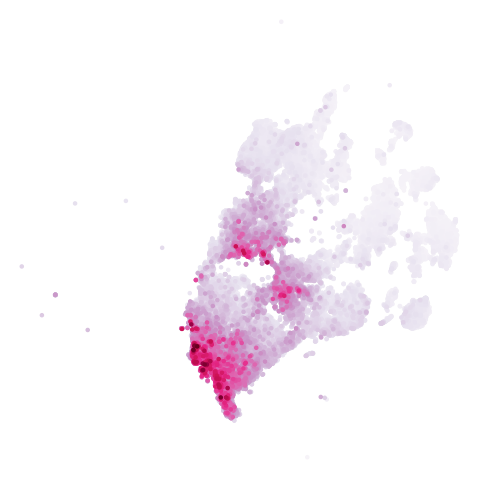

In [20]:
f = np.isin(annotation,['Tumor'])
plot_score( 
    neftelscore[:,1][f],
    emb[f,:],
    cmap='PuRd',
    s=5,
    figsize=(5,5),
    filename='NeftelScoreMES_Tumour'
)

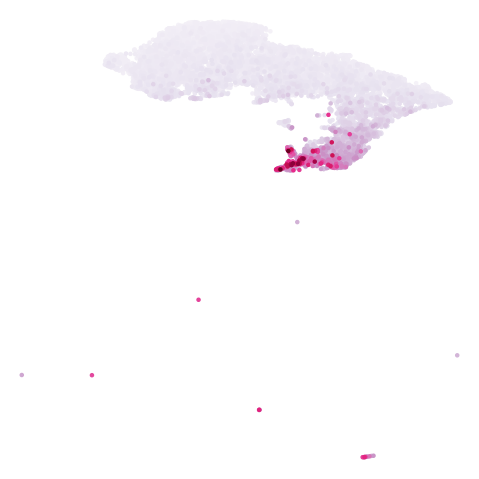

In [21]:
f = np.isin(annotation,['Oligodendrocytes'])
plot_score( 
    neftelscore[:,1][f],
    emb[f,:],
    s=5,
    cmap='PuRd',
    figsize=(5,5),
        filename='NeftelScoreMES_Oligo'
)

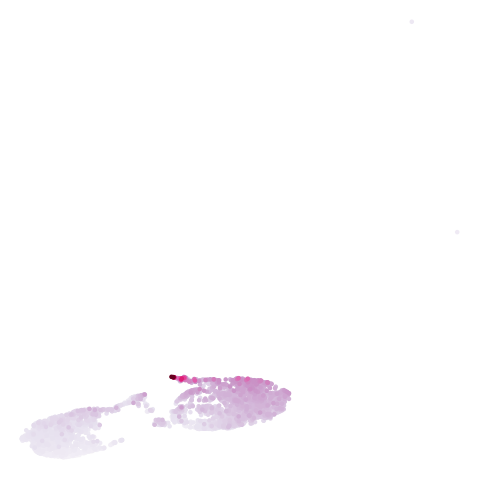

In [22]:
f = np.isin(annotation,['Astrocytes'])
plot_score( 
    neftelscore[:,1][f],
    emb[f,:],
    s=5,
    cmap='PuRd',
    figsize=(5,5),
        filename='NeftelScoreMES_Astrocytes'
)

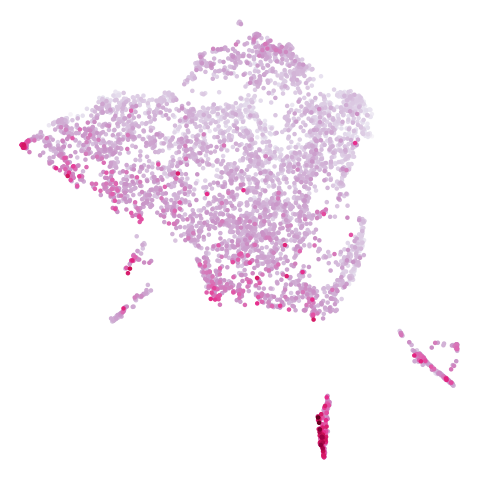

In [23]:
f = np.isin(annotation,['Endothelial'])
plot_score( 
    neftelscore[:,1][f],
    emb[f,:],
    s=5,
    cmap='PuRd',
    figsize=(5,5),
        filename='NeftelScoreMES_Endothelial'
)